In [ ]:
%pip install rank-bm25 ranx tiktoken langchain_text_splitters

In [ ]:
import numpy as np

from common import embeddings as E
from common.corpus import load_corpus
from common.goldset import load_queries, qrels
from common import retrieval as R


In [6]:
import re

from langchain_text_splitters import RecursiveCharacterTextSplitter

docs = load_corpus()


def chunk_absatz(docs, max_chars=550):
    """Strategie A: absatzweise packen (der Default aus common.retrieval)."""
    return R.chunk_corpus(docs, max_chars=max_chars)


def chunk_sliding(docs, size=400, overlap=80):
    """Strategie B: zeichenbasiertes Sliding-Window mit Überlappung."""
    out = []
    for d in docs:
        text = d.text
        step = max(1, size - overlap)
        i = idx = 0
        while i < len(text):
            piece = text[i:i + size].strip()
            if piece:
                out.append(R.Chunk(f"{d.doc_id}#s{idx}", d.doc_id, d.title, piece, d.acl))
                idx += 1
            i += step
    return out


def chunk_recursive(docs, size=400, overlap=60):
    """Strategie C: rekursiver Splitter (langchain), respektiert Trennzeichen."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=size, chunk_overlap=overlap,
        separators=["\n\n", "\n", ". ", " ", ""])
    out = []
    for d in docs:
        for idx, piece in enumerate(splitter.split_text(d.text)):
            piece = piece.strip()
            if piece:
                out.append(R.Chunk(f"{d.doc_id}#r{idx}", d.doc_id, d.title, piece, d.acl))
    return out


strategien = {
    "absatz":    chunk_absatz(docs),
    "sliding400": chunk_sliding(docs),
    "recursive400": chunk_recursive(docs),
}
for name, ch in strategien.items():
    laengen = [len(c.text) for c in ch]
    print(f"  {name:14s}: {len(ch):3d} Chunks, Median {int(np.median(laengen)):3d} Zeichen")


  absatz        :  24 Chunks, Median 382 Zeichen
  sliding400    :  33 Chunks, Median 399 Zeichen
  recursive400  :  36 Chunks, Median 219 Zeichen


In [10]:
from ranx import Qrels, Run, evaluate # Metriken berechnen 

gold = Qrels(qrels())
queries = load_queries()

ergebnisse = []
runs = {}

for name, chunks in strategien.items():
    dense = R.DenseRetriever(chunks) # chunks embedden 
    run = {}
    for q in queries:
        doc_scores = R.collapse_to_docs(dense.search(q.text, k=10)) # 
        # Welche Dokumente wurden durch Top-10 Chunks gefunden?
        run[q.qid] = {doc: sc for doc, sc in doc_scores}
    runs[name] = run
    m = evaluate(gold, Run(run, name = name), ["ndcg@5", "recall@5", "mrr"])
    ergebnisse.append({"strategie": name, **{k: round(float(v), 3) for k, v in m.items()}})

import pandas as pd

df = pd.DataFrame(ergebnisse).set_index("strategie")
print(df)



c:\Users\Student\Desktop\QSkills_AI340\.venv\Lib\site-packages\ranx\metrics\ndcg.py:72: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  scores[i] = _ndcg(qrels[i], run[i], k, rel_lvl, jarvelin)


              ndcg@5  recall@5    mrr
strategie                            
absatz         0.874     0.958  0.892
sliding400     0.857     0.958  0.861
recursive400   0.945     0.958  1.000


Diagramm gespeichert: media_lab05_chunking.png


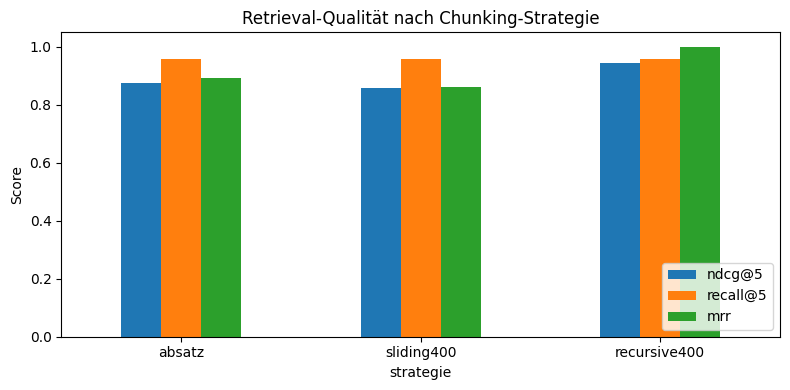

In [11]:
try:
    get_ipython()          # in Jupyter vorhanden: Inline-Backend
except NameError:
    import matplotlib, warnings
    matplotlib.use("Agg")  # als Skript: kein Fenster
    warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")
import matplotlib.pyplot as plt

ax = df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_ylabel("Score")
ax.set_title("Retrieval-Qualität nach Chunking-Strategie")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("media_lab05_chunking.png", dpi=110)
print("Diagramm gespeichert: media_lab05_chunking.png")
plt.show()


In [13]:
# chunk_sliding, overlap = 0 und variieren die Chunk-Größe
# Berechnen Sie ndcg@5

for size in (200, 400, 800):
    for overlap in (40, 80, 120):
        chunks = chunk_sliding(docs, size=size, overlap=overlap)
        dense = R.DenseRetriever(chunks=chunks)
        run = {q.qid: {d: s for d, s in R.collapse_to_docs(dense.search(q.text, k=10))}
            for q in queries}
        ndcg = float(evaluate(gold, Run(run), ["ndcg@5"]))
        print(f"size={size:3d}, overlap={overlap}: {len(chunks):3d} Chunks, nDCG@5={ndcg:.3f}")




size=200, overlap=40:  59 Chunks, nDCG@5=0.951
size=200, overlap=80:  77 Chunks, nDCG@5=0.959
size=200, overlap=120: 112 Chunks, nDCG@5=0.921
size=400, overlap=40:  29 Chunks, nDCG@5=0.861
size=400, overlap=80:  33 Chunks, nDCG@5=0.857
size=400, overlap=120:  35 Chunks, nDCG@5=0.827
size=800, overlap=40:  18 Chunks, nDCG@5=0.788
size=800, overlap=80:  19 Chunks, nDCG@5=0.795
size=800, overlap=120:  20 Chunks, nDCG@5=0.832


In [ ]:
# Welche Query schwankt am stärksten?
# absatz vs slinding400 
# Welche Frage gewinnt oder verliert am meisten durch die Strategie?
for q in queries:
    a = float(evaluate(Qrels({q.qid: qrels()[q.qid]}), Run({q.qid: runs["absatz"][q.qid]}), ["ndcg@5"]))
    b = float(evaluate(Qrels({q.qid: qrels()[q.qid]}), Run({q.qid: runs["sliding400"][q.qid]}), ["ndcg@5"]))
    diff = a - b
    if abs(diff) > 0.05:
        print(f"  {q.qid} {q.text[:42]:42s} absatz-sliding = {diff:+.3f}")


  q01 Wie hoch ist der zulässige Dauerbetriebsdr absatz-sliding = +0.087
  q04 Mit welchem Anzugsmoment werden die Pumpen absatz-sliding = +0.369
  q08 Wie oft muss der Rücklauffilter getauscht  absatz-sliding = -0.160
  q10 Welcher Spitzendruck ist kurzzeitig zuläss absatz-sliding = -0.061
  q11 Was tun bei Kavitation (pfeifendes Geräusc absatz-sliding = -0.093


(1.0, 1.0)